# 03 — GNN : Graphe bipartite Transactions ↔ Cards

**Construction du graphe :**
- Nœuds : transactions + cards (card1)
- Arêtes bidirectionnelles : transaction ↔ card1
- Features nœuds : numériques QuantileTransformer + cat encodées
- Modèle : HeteroGraphSAGE (DGL)
- Split **train / val / test** temporel (60/20/20) sur les transactions labellisées
- Métriques **AUC-ROC + AUC-PR**

**⚠️ Prérequis :** `00_common_preprocessing.ipynb`

## 1. Install + imports

In [1]:
!pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.2/483.2 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import gc, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, torch.nn as nn, torch.nn.functional as F
import dgl, dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')

train = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/train_base.pkl')
test_kaggle  = pd.read_pickle('/kaggle/input/notebooks/simoben95/00-01common-preprocessing/test_kaggle.pkl')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(train.shape, test_kaggle.shape, '| Device:', device)

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
(590540, 427) (506691, 426) | Device: cpu


## 2. Concaténation full + préprocessing léger

On garde tout (train labellisé + kaggle non-labellisé) dans le graphe pour que le message passing propage l'info à travers toutes les transactions (transductif).

In [3]:
%%time
test_kaggle['isFraud'] = -1  # marqueur : pas de label
full = pd.concat([train, test_kaggle], ignore_index=True)
n_train_labeled = len(train)

cat_cols = [c for c in full.columns if full[c].dtype == 'object']
for c in cat_cols:
    le = LabelEncoder()
    full[c] = le.fit_transform(full[c].astype(str).fillna('missing'))
print('Cat encoded, full shape:', full.shape)

Cat encoded, full shape: (1097231, 427)
CPU times: user 16.8 s, sys: 4.14 s, total: 21 s
Wall time: 21 s


## 3. Split train / val / test temporel (sur les LABELLISÉS uniquement)

In [4]:
# On trie les labellisés par TransactionDT pour faire le split temporel
labeled_sorted_idx = full.iloc[:n_train_labeled].sort_values('TransactionDT').index.values
n = len(labeled_sorted_idx); i1, i2 = int(n*0.6), int(n*0.8)

train_idx = torch.tensor(labeled_sorted_idx[:i1],      dtype=torch.long)
val_idx   = torch.tensor(labeled_sorted_idx[i1:i2],    dtype=torch.long)
test_idx  = torch.tensor(labeled_sorted_idx[i2:],      dtype=torch.long)
kaggle_idx= torch.tensor(np.arange(n_train_labeled, len(full)), dtype=torch.long)
print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,} | Kaggle: {len(kaggle_idx):,}')

Train: 354,324 | Val: 118,108 | Test: 118,108 | Kaggle: 506,691


## 4. Construction du graphe bipartite

In [5]:
tx_ids = np.arange(len(full))
card_ids = full['card1'].values
unique_cards, card_idx = np.unique(card_ids, return_inverse=True)
print(f'Transactions: {len(tx_ids):,} | Unique cards: {len(unique_cards):,}')

g = dgl.heterograph({
    ('transaction', 'uses',    'card'):        (tx_ids, card_idx),
    ('card',        'used_by', 'transaction'): (card_idx, tx_ids),
})
print(g)

Transactions: 1,097,231 | Unique cards: 17,091
Graph(num_nodes={'card': 17091, 'transaction': 1097231},
      num_edges={('card', 'used_by', 'transaction'): 1097231, ('transaction', 'uses', 'card'): 1097231},
      metagraph=[('card', 'transaction', 'used_by'), ('transaction', 'card', 'uses')])


## 5. Features de nœuds

In [6]:
num_cols = [c for c in full.columns
            if c not in ['isFraud','TransactionID','TransactionDT','DT_M'] and full[c].dtype != 'object']
feats = full[num_cols].fillna(-999).values.astype(np.float32)

qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42, subsample=200000)
feats = qt.fit_transform(feats).astype(np.float32)

g.nodes['transaction'].data['feat'] = torch.tensor(feats)

# Feature card = moyenne des features de ses transactions
card_feat = np.zeros((len(unique_cards), feats.shape[1]), dtype=np.float32)
np.add.at(card_feat, card_idx, feats)
counts = np.bincount(card_idx, minlength=len(unique_cards)).reshape(-1,1)
card_feat = card_feat / np.maximum(counts, 1)
g.nodes['card'].data['feat'] = torch.tensor(card_feat)
print(f'Tx feat: {feats.shape} | Card feat: {card_feat.shape}')

Tx feat: (1097231, 423) | Card feat: (17091, 423)


## 6. Modèle HeteroGraphSAGE

In [7]:
class HeteroSAGE(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super().__init__()
        self.conv1 = dglnn.HeteroGraphConv({
            'uses':    dglnn.SAGEConv(in_dim,  hid_dim, 'mean'),
            'used_by': dglnn.SAGEConv(in_dim,  hid_dim, 'mean'),
        })
        self.conv2 = dglnn.HeteroGraphConv({
            'uses':    dglnn.SAGEConv(hid_dim, hid_dim, 'mean'),
            'used_by': dglnn.SAGEConv(hid_dim, hid_dim, 'mean'),
        })
        self.classifier = nn.Linear(hid_dim, out_dim)
    def forward(self, g, x):
        x = {k: v.float() for k, v in x.items()}
        h = self.conv1(g, x)
        h = self.conv1(g, x); h = {k: F.relu(v) for k,v in h.items()}
        h = self.conv2(g, h); h = {k: F.relu(v) for k,v in h.items()}
        return self.classifier(h['transaction'])

## 7. Training (early stopping sur val AUC-PR)

In [8]:
%%time
labels = torch.tensor(full['isFraud'].values, dtype=torch.long)

g = g.to(device)
x = {'transaction': g.nodes['transaction'].data['feat'],
     'card':        g.nodes['card'].data['feat']}
labels = labels.to(device)
train_idx = train_idx.to(device); val_idx = val_idx.to(device)
test_idx  = test_idx.to(device);  kaggle_idx = kaggle_idx.to(device)

model = HeteroSAGE(feats.shape[1], 128, 2).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
pos_weight = torch.tensor([1.0, (labels[train_idx]==0).sum().item()/max((labels[train_idx]==1).sum().item(),1)]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
# ------------------
# model = model.double()
best_pr, best_probs, patience, bad = 0, None, 5, 0
for epoch in range(50):
    model.train()
    logits = model(g, x)
    loss = loss_fn(logits[train_idx], labels[train_idx])
    opt.zero_grad(); loss.backward(); opt.step()

    if epoch % 2 == 0:
        model.eval()
        with torch.no_grad():
            probs = F.softmax(model(g, x), dim=1)[:, 1].cpu().numpy()
        y_v = labels[val_idx].cpu().numpy()
        p_v = probs[val_idx.cpu().numpy()]
        auc = roc_auc_score(y_v, p_v); pr = average_precision_score(y_v, p_v)
        print(f'Epoch {epoch:2d} | loss {loss.item():.4f} | val AUC-ROC {auc:.4f} | val AUC-PR {pr:.4f}')
        if pr > best_pr:
            best_pr, best_probs, bad = pr, probs, 0
        else:
            bad += 1
            if bad >= patience: print('Early stop'); break

Epoch  0 | loss 1.2882 | val AUC-ROC 0.6503 | val AUC-PR 0.0827
Epoch  2 | loss 0.8133 | val AUC-ROC 0.7654 | val AUC-PR 0.1184
Epoch  4 | loss 0.7274 | val AUC-ROC 0.7902 | val AUC-PR 0.1372
Epoch  6 | loss 0.6153 | val AUC-ROC 0.8148 | val AUC-PR 0.1883
Epoch  8 | loss 0.5769 | val AUC-ROC 0.8136 | val AUC-PR 0.2127
Epoch 10 | loss 0.5700 | val AUC-ROC 0.8174 | val AUC-PR 0.2554
Epoch 12 | loss 0.5300 | val AUC-ROC 0.8401 | val AUC-PR 0.2863
Epoch 14 | loss 0.5043 | val AUC-ROC 0.8484 | val AUC-PR 0.3175
Epoch 16 | loss 0.5134 | val AUC-ROC 0.8474 | val AUC-PR 0.3177
Epoch 18 | loss 0.5031 | val AUC-ROC 0.8535 | val AUC-PR 0.3319
Epoch 20 | loss 0.4782 | val AUC-ROC 0.8567 | val AUC-PR 0.3456
Epoch 22 | loss 0.4777 | val AUC-ROC 0.8514 | val AUC-PR 0.3346
Epoch 24 | loss 0.4769 | val AUC-ROC 0.8585 | val AUC-PR 0.3621
Epoch 26 | loss 0.4641 | val AUC-ROC 0.8649 | val AUC-PR 0.3861
Epoch 28 | loss 0.4585 | val AUC-ROC 0.8671 | val AUC-PR 0.4021
Epoch 30 | loss 0.4561 | val AUC-ROC 0.8

## 8. Évaluation sur val ET test

In [9]:
%%time
results = []
def evaluate(y_true, y_pred, name, split_name, ax_roc=None, ax_pr=None, color=None):
    auc_roc = roc_auc_score(y_true, y_pred); auc_pr = average_precision_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred); pr, rc, _ = precision_recall_curve(y_true, y_pred)
    if ax_roc is not None: ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc_roc:.4f})')
    if ax_pr  is not None: ax_pr.plot(rc, pr,   color=color, label=f'{name} (AP={auc_pr:.4f})')
    print(f'  {split_name:5s} | AUC-ROC: {auc_roc:.4f} | AUC-PR: {auc_pr:.4f}')
    results.append({'model':name,'split':split_name,'auc_roc':auc_roc,'auc_pr':auc_pr})

y_val_np  = labels[val_idx].cpu().numpy();  p_val = best_probs[val_idx.cpu().numpy()]
y_test_np = labels[test_idx].cpu().numpy(); p_test = best_probs[test_idx.cpu().numpy()]

print('GNN:'); evaluate(y_val_np,  p_val,  'GNN', 'val')
evaluate(y_test_np, p_test, 'GNN', 'test')

GNN:
  val   | AUC-ROC: 0.8800 | AUC-PR: 0.4635
  test  | AUC-ROC: 0.8557 | AUC-PR: 0.3825
CPU times: user 217 ms, sys: 767 µs, total: 218 ms
Wall time: 198 ms


## 9. Courbes ROC & PR (sur test)

  test  | AUC-ROC: 0.8557 | AUC-PR: 0.3825


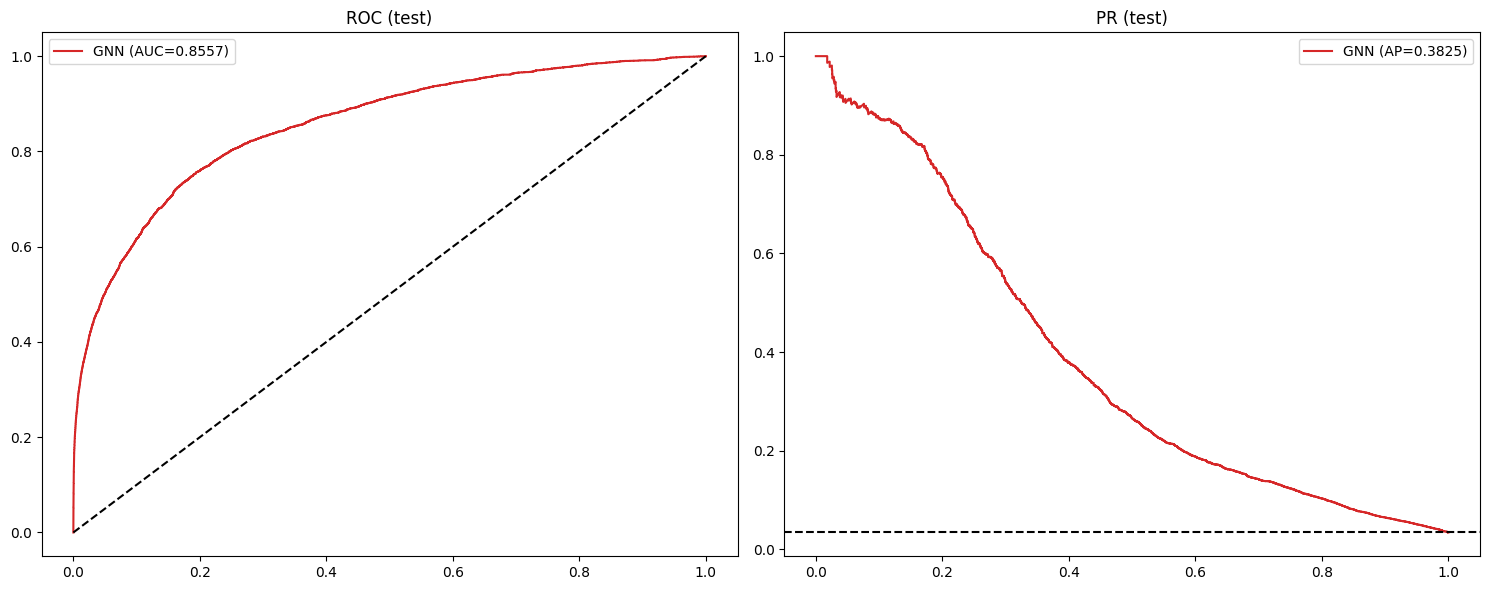

,model,split,auc_roc,auc_pr
0,GNN,val,0.879994,0.463487
1,GNN,test,0.855748,0.382490
2,GNN,test,0.855748,0.382490


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
evaluate(y_test_np, p_test, 'GNN', 'test', ax1, ax2, 'C3')
ax1.plot([0,1],[0,1],'k--'); ax1.set_title('ROC (test)'); ax1.legend()
ax2.axhline(y_test_np.mean(), color='k', ls='--'); ax2.set_title('PR (test)'); ax2.legend()
plt.tight_layout(); plt.show()
pd.DataFrame(results)

## 10. Soumission Kaggle

In [11]:
test_pred = best_probs[kaggle_idx.cpu().numpy()]
sub = pd.DataFrame({'TransactionID': test_kaggle['TransactionID'].values, 'isFraud': test_pred})
sub.to_csv('/kaggle/working/submission_gnn.csv', index=False)
print(sub.head())

   TransactionID   isFraud
0        3663549  0.099712
1        3663550  0.478095
2        3663551  0.471152
3        3663552  0.084352
4        3663553  0.170498
